In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import os

_, name = os.path.split(os.getcwd())
if name=="notebooks":
    os.chdir("../.")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl
import seaborn as sns

In [4]:
import os
# os.environ["HTTPS_PROXY"]=""
# os.environ["https_proxy"]=""

In [30]:
import wandb

api = wandb.Api()
runs = api.runs("itsc2026")

# Get histories for all runs with specific metrics
# histories = runs.histories(format="pandas")
all_results = pl.DataFrame({**run.config, **run.summary} for run in runs).with_columns(
    (pl.col._timestamp * 1000).cast(pl.Datetime("ms"))
)
all_results.columns

['data',
 'name',
 'seed',
 'model',
 'kalman',
 'fourdvar',
 'dx_meters',
 'dt_seconds',
 '_runtime',
 '_step',
 '_timestamp',
 '_wandb',
 'rmse',
 'flow']

# Main sweep

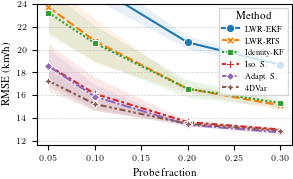

In [19]:
# experiment_keys = ["name", "model", "probe_fraction"]
from traffic_models.plot.utils import rcparams

experiments = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "itsc_v4"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .rename(dict(name="sweep_name"))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("data").rename({col: f"data.{col}" for col in all_results["data"].struct.fields})
    # .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .select(
        pl.col.model.replace({"Identity-EKF":"Identity-KF", "ASM":"Adapt. S.", "isotropic-smoothing":"Iso. S."}),
        # pl.col.data.struct.field("name").alias("dataset"),
        pl.col.data.struct.field("probe_fraction"),
        pl.col.data.struct.field("boundary_fraction"),
        pl.col.rmse,
        pl.col.hidden_rmse,
        pl.col.seed,
    )
    .filter(pl.col.seed<10) # i did 11 seeds by mistake
    # .filter(pl.col.boundary_fraction==1.0)
    .remove(pl.col.probe_fraction>0.3)
    # .remove(model="LWR-EKF")
)
# agg_results = (
#     experiments
#     .pivot(
#     index=["model"],
#     on=["probe_fraction"],
#     values="rmse",
#     aggregate_function=
#     #   pl.len(),
#      "$"+pl.element().mean().cast(pl.Utf8).str.head(4)+r"\pm"+pl.element().std().cast(pl.Utf8).str.head(4)+"$",
#     )
#     .transpose(include_header=True)
#     .sort("column")
#     .transpose(include_header=False)
#     # .sort("column")
# )
# agg_results
# print(agg_results.to_pandas().to_latex(index=False).replace(r"\pm0.", r"\pm."))
plt.rcParams.update(rcparams(ieee=True, columns=1))
ax: plt.Axes = sns.lineplot(
    data=experiments.sort(by=["probe_fraction", "rmse"], descending=[False, True]).to_pandas(),
    x="probe_fraction",
    y="hidden_rmse",
    hue="model",
    style="model",
    markers=True,
    # dashes=False,
    errorbar="sd",
    err_kws={"linewidth": 0, "alpha": 0.1}
)
plt.legend(title="Method")
plt.xlabel("Probe fraction")
plt.ylabel("RMSE (km/h)");
_grid: None = ax.grid(axis="y", which="major", linestyle="--", linewidth=0.5, alpha=0.6)
plt.ylim(top=24)
plt.savefig("output_plots/itsc/boundary_sweep_rmse_v2.pdf", bbox_inches="tight")
# ax.set_yscale("log")
# ax.set_xscale("log")
# px.line(
#     tab_results #.group_by(["model", "probe_fraction"]).agg(pl.col("rmse").mean())
#     .sort("probe_fraction"),
#     x="probe_fraction",
#     y="rmse",
#     color="model",
#     log_y=True,
#     # markers=True,
# )

In [9]:
(
    experiments
    .pivot(
    index=["model"],
    on=["probe_fraction"],
    values="hidden_rmse",
    aggregate_function=
      pl.len(),
    )
    # .sort("column")
)

model,0.05,0.1,0.2,0.3
str,u32,u32,u32,u32
"""4DVar""",10,10,10,10
"""Adapt. S.""",10,10,10,10
"""Iso. S.""",10,10,10,10
"""Identity-KF""",10,10,10,10
"""LWR-EKF""",10,10,10,10
"""LWR-RTS""",10,10,10,10


## Ablation sweep

C:\Users\a055963\AppData\Local\Temp\ipykernel_19564\3520033483.py:83: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.stripplot(


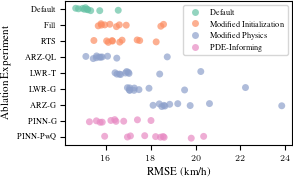

In [42]:
# experiment_keys = ["name", "model", "probe_fraction"]
from traffic_models.plot.utils import rcparams


ablations = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "itsc_ablation_v3" or run.config.get("name") == "itsc_v4"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
    # .unnest("fourdvar").rename({col: f"fourdvar.{col}" for col in all_results["fourdvar"].struct.fields})
    .select(
        pl.col.model.replace({"Identity-EKF": "Identity-KF"}),
        # pl.col.data.struct.field("name").alias("dataset"),
        pl.col.data.struct.field("probe_fraction"),
        pl.col.fourdvar.struct.field("fundamental_diagram"),
        pl.col.fourdvar.struct.field("init"),
        pl.col.fourdvar.struct.field("solver"),
        pl.col.fourdvar.struct.field("velocity_model_variance"),
        pl.col.fourdvar.struct.field("learn_flow"),
        pl.col.fourdvar.struct.field("n_windows"),
        pl.col.flow.struct.field("flux_function").struct.field("v_max"),
        pl.col.data.struct.field("ramps"),
        pl.col.rmse,
        pl.col.hidden_rmse,
        pl.col.seed,
    )
    .remove(solver="lax_friedrichs") # not working
    .filter(pl.col.ramps)
    # .remove((pl.col.init=="rts") & (pl.col.velocity_model_variance==0.01)) # suboptimal
    # .remove((pl.col.init=="forward_fill") & (pl.col.velocity_model_variance==0.01)) # suboptimal
    # .remove((pl.col.fundamental_diagram=="ARZGreenshields") & ~(pl.col.learn_flow)) # suboptimal
    .remove((pl.col.fundamental_diagram=="ARZGreenshields") & (pl.col.velocity_model_variance==0.1)) # suboptimal
    # .remove((pl.col.fundamental_diagram=="ARZQuadraticLinear") & (pl.col.learn_flow)) # suboptimal
    # .remove((pl.col.fundamental_diagram=="ARZGreenshields") & (pl.col.v_max!=30)) 
    .filter((pl.col.model=="4DVar")|(pl.col.model=="PINN"))
    .filter(probe_fraction=0.1)
    .filter(pl.col.seed < 10)  # i did 11 seeds by mistake
    .filter(pl.col.init!="naive_rollout") # not needed
    # .filter(pl.col.velocity_model_variance==2.0)
)
# print(agg_results.to_pandas().to_latex(index=False).replace(r"\pm0.", r"\pm."))
plt.rcParams.update(rcparams(ieee=True, columns=1))
plot_data = (ablations.with_columns(
        ablation=pl.concat_str(["model", "fundamental_diagram", "solver", "init"], separator="-")
    .replace({
        "4DVar-ARZPiecewiseQuadratic-rusanov-naive_smoothing": "Default",
        "4DVar-ARZPiecewiseQuadratic-lax_friedrichs-naive_smoothing": "LaxF",
        "4DVar-ARZGreenshields-rusanov-naive_smoothing": "ARZ-G",
        "4DVar-ARZQuadraticLinear-rusanov-naive_smoothing": "ARZ-QL",
        "4DVar-LWRTriangular-godunov-naive_smoothing": "LWR-T",
        "4DVar-LWRGreenshields-godunov-naive_smoothing": "LWR-G",
        "4DVar-ARZPiecewiseQuadratic-rusanov-rts": "RTS",
        "4DVar-ARZPiecewiseQuadratic-rusanov-forward_fill": "Fill",
        "4DVar-ARZPiecewiseQuadratic-rusanov-naive_rollout": "Rollout",
        "PINN-ARZGreenshields-rusanov-naive_smoothing": "PINN-G",
        "PINN-ARZPiecewiseQuadratic-rusanov-naive_smoothing": "PINN-PwQ",
    }),
        change=pl.concat_str(["model", "fundamental_diagram", "solver", "init"], separator="-")
    .replace({
        "4DVar-ARZPiecewiseQuadratic-rusanov-naive_smoothing": "Default",
        "4DVar-ARZPiecewiseQuadratic-lax_friedrichs-naive_smoothing": "Modified Solver",
        "4DVar-ARZGreenshields-rusanov-naive_smoothing": "Modified Physics",
        "4DVar-ARZQuadraticLinear-rusanov-naive_smoothing": "Modified Physics",
        "4DVar-LWRTriangular-godunov-naive_smoothing": "Modified Physics",
        "4DVar-LWRGreenshields-godunov-naive_smoothing": "Modified Physics",
        "4DVar-ARZPiecewiseQuadratic-rusanov-rts": "Modified Initialization",
        "4DVar-ARZPiecewiseQuadratic-rusanov-forward_fill": "Modified Initialization",
        "4DVar-ARZPiecewiseQuadratic-rusanov-naive_rollout": "Modified Initialization",
        "PINN-ARZGreenshields-rusanov-naive_smoothing": "PDE-Informing",
        "PINN-ARZPiecewiseQuadratic-rusanov-naive_smoothing": "PDE-Informing",
    })
    )
    .with_columns(change=pl.when(~pl.col.ramps).then(pl.lit("Modified Boundaries")).otherwise(pl.col.change))
    .with_columns(ablation=pl.when(~pl.col.ramps).then(pl.lit("No ramps")).otherwise(pl.col.ablation))
    .remove(pl.col.rmse>30) # hide failed runs
    .unique(subset=["seed", "ablation"], keep="first") 
    .sort(pl.col.change,pl.col.hidden_rmse.mean().over("ablation"),)
)
ax = sns.stripplot(
    data=plot_data,
    y="ablation",
    x="hidden_rmse",
    hue="change",
    alpha=0.7,
    # orient="h",
    # errorbar="ci",
    # err_kws={"linewidth": 1.0},
    # capsize=0.2,
    palette=sns.color_palette("Set2", as_cmap=False)
)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',)
plt.legend()
plt.ylabel("Ablation Experiment")
plt.xlabel("RMSE (km/h)")
# plt.xlim(left=10)
plt.savefig(f"output_plots/itsc/ablation_sweep_rmse_v3.pdf", bbox_inches="tight")
# ax.set_yscale("log")
# px.line(
#     tab_results #.group_by(["model", "probe_fraction"]).agg(pl.col("rmse").mean())
#     .sort("probe_fraction"),
#     x="probe_fraction",
#     y="rmse",
#     color="model",
#     log_y=True,
#     # markers=True,
# )

In [32]:
plot_data.group_by("ablation").agg(pl.len(), pl.col.seed.n_unique(),pl.col.rmse.mean(), pl.col.rmse.std().alias("rmse_std"))

ablation,len,seed,rmse,rmse_std
str,u32,u32,f64,f64
"""ARZ-QL""",10,10,15.232034,0.994046
"""PINN-G""",10,10,15.700496,0.834388
"""ARZ-G""",10,10,18.526974,1.655966
"""LWR-G""",10,10,17.111874,1.615014
"""Default""",10,10,14.491962,0.543348
"""LWR-T""",10,10,16.437184,1.150872
"""Fill""",10,10,15.810522,1.045683
"""PINN-PwQ""",10,10,17.381225,1.25264
"""RTS""",10,10,15.835913,0.815286
